<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/Breast_Cancer_Wisconsin_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Работа 2_2

Цель работы:
Познакомиться с алгоритмом k-ближайших соседей (KNN), изучить его работу на реальных данных и научиться оценивать качество классификации.

Датасет:
В ноутбуке используется датасет Breast Cancer Wisconsin (Диагностика рака молочной железы).

Содержит признаки клеток опухоли (30 числовых признаков, таких как площадь, радиус, текстура и т.д.).

Признаки: 30 числовых характеристик клеток опухоли (например, размер, форма, текстура).

Целевая переменная: diagnosis

M — злокачественная опухоль (Malignant)

B — доброкачественная опухоль (Benign)

##Шаг 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Пояснение:

pandas и numpy — для работы с таблицами и массивами

matplotlib и seaborn — для графиков

train_test_split — делим данные на тренировочные и тестовые

KNeighborsClassifier — готовый KNN

accuracy_score и confusion_matrix — проверка качества модели

##Шаг 2. Загрузка и подготовка данных

2.1 Считайте данные с помощью функции pd.read_csv() и ссылки на датасет: https://raw.githubusercontent.com/melwinlobo18/K-Nearest-Neighbors/master/Dataset/data.csv

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/melwinlobo18/K-Nearest-Neighbors/master/Dataset/data.csv")

2.2. Посмотрите на первые строки:

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


2.3. Посмотрите размер и типы данных:

In [ ]:
df.shape

(569, 33)

Пояснение:

head() — первые 5 строк

shape — сколько строк и столбцов

info() — типы данных и пропущенные значения

describe() — статистика по числовым столбцам

##Шаг 3. Подготовка данных

3.1. Преобразуем метки diagnosis в числа:

In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


Посмотрите на датафрейм после преобразования, что изменилось?

M (Malignant) → 1

B (Benign) → 0

Зачем: алгоритмы ML работают с числами, а не с буквами.

3.2. Удалите ненужные столбцы (например, ID)  с помощью df = df.drop(['name', 'name'], axis=1)

In [ ]:
df = df.drop(['id', 'Unnamed: 32'],axis = 1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


3.3 Выполните проверку на пропуски

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


##Шаг 4. Исследование и визуализация данных

4.1. Посчитайте количество объектов каждого класса

In [ ]:
class_counts = df['diagnosis'].value_counts()
print(class_counts)

diagnosis
0    357
1    212
Name: count, dtype: int64


4.2 Постройте pair plot по 2-3 признакам

sns.pairplot(df, vars=['name','name','name'], hue='diagnosis')
plt.show()




Pairplot показывает, как объекты разных классов разделяются по выбранным признакам

##Шаг 5. Разделение на тренировочную и тестовую выборку

5.1 Выполните разделение данных на тестовую и тренировочную выборку, объясните для чего это нужно

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Размер X (признаки):", X.shape)
print("Размер y (целевая переменная):", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print("Обучающая выборка (признаки):", X_train.shape)
print("Обучающая выборка (цели):", y_train.shape)
print("Тестовая выборка (признаки):", X_test.shape)
print("Тестовая выборка (цели):", y_test.shape)


Размер X (признаки): (569, 30)
Размер y (целевая переменная): (569,)
Обучающая выборка (признаки): (398, 30)
Обучающая выборка (цели): (398,)
Тестовая выборка (признаки): (171, 30)
Тестовая выборка (цели): (171,)


70% данных — тренировочные, 30% — тестовые

random_state фиксирует случайное разбиение

##Шаг 6. Обучение модели KNN

6.1 Выполните обучение модели KNN с помощью KNeighborsClassifier и функции fit

k=5 → берём 5 ближайших соседей

fit — “обучаем” модель (для KNN это просто сохранение данных)

##шаг 7. Предсказание и оценка точности

7.1 Сделайте предсказания на тестовой выборке

Создайте переменную y_pred и присвойте ей результат работы метода predict модели knn для тестовых признаков X_test.

7.2 Вычислите точность модели

Создайте переменную accuracy и используйте функцию accuracy_score, чтобы сравнить предсказанные метки y_pred с настоящими метками y_test.

Выведите результат на экран, например, с двумя знаками после запятой.

7.3 Постройте матрицу ошибок (confusion matrix)

Создайте переменную cm и присвойте ей результат функции confusion_matrix для y_test и y_pred.

Визуализируйте матрицу ошибок с помощью sns.heatmap: подпишите оси, включите аннотации внутри ячеек (annot=True), задайте цветовую карту, например Blues.

##Шаг 8. Выводы

Сколько объектов каждого класса

Какие признаки лучше разделяют классы (по графикам pairplot)

Насколько точен KNN на тестовой выборке

Как интерпретировать результаты через confusion matrix

#2.2 часть

###Ручная реализация алгоритма k-ближайших соседей (KNN)


Цель: реализовать алгоритм KNN вручную (без использования sklearn), чтобы понять его внутреннюю логику.

Используйте уже подготовленный датасет Breast Cancer.

Убедитесь, что:

Целевая переменная diagnosis преобразована в 0 и 1

Удалены столбцы id и Unnamed: 32

Данные разделены на:

X — признаки

y — целевая переменная

Выполнено разделение на:

X_train, X_test

y_train, y_test

Если всё это уже сделано в части 2.1 — повторно ничего делать не нужно.

Перед реализацией алгоритма необходимо проверить структуру данных.

Посмотрите размерности выборок с помощью атрибута shape, пример: `print("Размер X_train:", X_train.shape)`

In [ ]:
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (398, 30)
Размер X_test: (171, 30)
Размер y_train: (398,)
Размер y_test: (171,)


Ответьте:

Сколько объектов в обучающей выборке?

Сколько объектов в тестовой?

Сколько признаков у каждого объекта?

Посмотрите первые строки X_train, y_train

In [ ]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
78,20.18,23.97,143.70,1245.0,0.12860,0.34540,0.37540,0.16040,0.2906,0.08142,...,23.37,31.72,170.30,1623.0,0.1639,0.6164,0.7681,0.2508,0.5440,0.09964
330,16.03,15.51,105.80,793.2,0.09491,0.13710,0.12040,0.07041,0.1782,0.05976,...,18.76,21.98,124.30,1070.0,0.1435,0.4478,0.4956,0.1981,0.3019,0.09124
378,13.66,15.15,88.27,580.6,0.08268,0.07548,0.04249,0.02471,0.1792,0.05897,...,14.54,19.64,97.96,657.0,0.1275,0.3104,0.2569,0.1054,0.3387,0.09638
213,17.42,25.56,114.50,948.0,0.10060,0.11460,0.16820,0.06597,0.1308,0.05866,...,18.07,28.07,120.40,1021.0,0.1243,0.1793,0.2803,0.1099,0.1603,0.06818
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.09966,0.07064,0.2116,0.06346,...,16.34,18.24,109.40,803.6,0.1277,0.3089,0.2604,0.1397,0.3151,0.08473


In [ ]:
y_train.head()

,diagnosis
78,1
330,1
378,0
213,1
89,0


Что содержит X_train?

Что содержит y_train?

Совпадает ли количество строк?

Проверьте типы данных X_train, y_train

In [ ]:
print(type(X_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


###Шаг 2.2 Математическая основа алгоритма

Для удобства реализации алгоритма переведём данные в numpy-массивы.

In [ ]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

Проверьте ещё раз типы: X_train, y_train

In [ ]:
print("X_train:", type(X_train))
print("y_train:", type(y_train))
print("X_test:", type(X_test))
print("y_test:", type(y_test))

X_train: <class 'numpy.ndarray'>
y_train: <class 'numpy.ndarray'>
X_test: <class 'numpy.ndarray'>
y_test: <class 'numpy.ndarray'>


Перейдем к реализации алгоритма и начнем с евклидова расстояния.

Для начала определим метрику, по которой будем определять расстояние между объектами. Обозначим через $x = (x_1, x_2, \ldots, x_n)$ координаты объекта $x$ в n-мерном пространстве, а через $y = (y_1, y_2, \ldots, y_n)$ - координаты объекта $y$.

По умолчанию алгоритм использует метрику Минковского, которая в случае степени p = 2 обращается во всем известную из школьной геометрии Евклидову метрику - расстояние между двумя точками в пространстве:
$$
dist = \sqrt{(x_1-y_1)^2 + (x_2 - y_2)^2 + \ldots + (x_n - y_n)^2}
$$
Ее и будем использовать.

где:

𝑥 — первый объект

𝑦— второй объект

𝑛— количество признаков

 Интерпретация:

Каждый объект — это точка в 30-мерном пространстве (по количеству признаков).
Расстояние показывает, насколько объекты похожи.
Чем меньше расстояние — тем объекты более похожи.

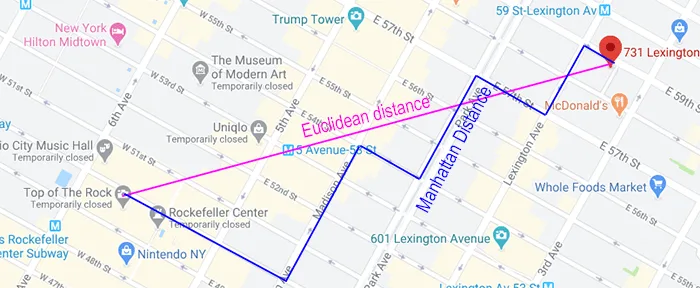

Реализуйте функцию Евклидова расстояния.

In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))
print(euclidean_distance(X_train[0], X_train[1]))

1180.8169518259401


Что означает len(x1)?

Почему мы проходим по всем признакам?

Что происходит внутри цикла?

###Шаг 2.3 Поиск k ближайших соседей

Теперь нужно:

Посчитать расстояние от одного тестового объекта до всех объектов обучающей выборки.

Отсортировать расстояния.

Выбрать k ближайших.

X_train — обучающие признаки

y_train — классы обучающей выборки

test_instance — один объект, для которого ищем соседей

k — сколько соседей брать

Реализуйте функцию `def get_neighbors(X_train, y_train, test_instance, k=5):`

In [ ]:
def get_neighbors(X_train, y_train, test_instance, k=5):
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], test_instance)
        distances.append((y_train[i], dist))

    distances.sort(key=lambda x: x[1])

    neighbors = []
    for i in range(k):
        neighbors.append(distances[i][0])

    return neighbors

Что хранится в списке distances?

Почему мы сортируем по x[1]?

Что возвращает функция?

###Шаг 2.4 Голосование (определение класса)

Теперь нужно определить класс на основе большинства голосов.

Реализуйте функцию `def predict_classification(neighbors):`

In [ ]:
def predict_classification(neighbors):
    counts = {}

    for label in neighbors:
        if label in counts:
            counts[label] += 1
        else:
            counts[label] = 1

    return max(counts, key=counts.get)

Что хранится в словаре counts?

Почему используется функция max()?

Что произойдет при k = 1?

###Шаг 2.5 Оценка точности
Реализуйте функцию вычисления accuracy вручную.

$Accuracy = \frac{TP+TF}{TP+TF+FP+FN}$

In [ ]:
def accuracy_manual(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / len(y_true)

###Шаг 2.6 Проверьте работу алгоритма

In [ ]:
predictions = []

for i in range(len(X_test)):
    neighbors = get_neighbors(X_train, y_train, X_test[i], k=5)
    result = predict_classification(neighbors)
    predictions.append(result)
    print(f"Объект {i}: предсказано={result}, реально={y_test[i]}")

accuracy = accuracy_manual(y_test, predictions)
print(f"\nТочность модели: {accuracy:.2f}")

Объект 0: предсказано=0, реально=0
Объект 1: предсказано=0, реально=0
Объект 2: предсказано=0, реально=0
Объект 3: предсказано=0, реально=0
Объект 4: предсказано=0, реально=0
Объект 5: предсказано=0, реально=0
Объект 6: предсказано=1, реально=1
Объект 7: предсказано=0, реально=0
Объект 8: предсказано=0, реально=1
Объект 9: предсказано=0, реально=0
Объект 10: предсказано=0, реально=0
Объект 11: предсказано=1, реально=1
Объект 12: предсказано=0, реально=0
Объект 13: предсказано=0, реально=0
Объект 14: предсказано=0, реально=0
Объект 15: предсказано=0, реально=0
Объект 16: предсказано=0, реально=0
Объект 17: предсказано=1, реально=1
Объект 18: предсказано=1, реально=1
Объект 19: предсказано=1, реально=1
Объект 20: предсказано=1, реально=1
Объект 21: предсказано=1, реально=1
Объект 22: предсказано=1, реально=1
Объект 23: предсказано=0, реально=0
Объект 24: предсказано=0, реально=0
Объект 25: предсказано=0, реально=1
Объект 26: предсказано=1, реально=1
Объект 27: предсказано=1, реально=1
Об

Выполните ручной расчет accuracy, вызвав ранее реализованную функцию

In [ ]:
accuracy = accuracy_manual(y_test, predictions)
print(f"Точность модели (ручной расчет): {accuracy:.2f}")

Точность модели (ручной расчет): 0.93


###Выводы

Необходимо знать ответы на вопросы

Как работает алгоритм KNN?

Почему его называют "ленивым"?

Как влияет параметр k?

Почему важно масштабирование признаков?